## Setup

In [1]:
import os
import hashlib
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

IMG_SIZE    = (256, 256)
CLASS_NAMES = ['Brown_Rust', 'Healthy', 'Yellow_Rust']
NUM_CLASSES = len(CLASS_NAMES)
BATCH_SIZE  = 32

MODEL_PATH = 'wheat_disease_cnn.keras'      

KAGGLE_INPUT = '/kaggle/input/behzad-safari-jalal/data'
if os.path.isdir(KAGGLE_INPUT):
    PAPER_DIR = KAGGLE_INPUT
else:
    import kagglehub
    PAPER_DIR = os.path.join(kagglehub.dataset_download('sinadunk23/behzad-safari-jalal'),
                             'data')


ARCHIVE_CANDIDATES = [
    'archive/Dataset',
    r'C:\Users\HP\Downloads\neural-network\archive\Dataset',
]
ARCHIVE_DIR = next((p for p in ARCHIVE_CANDIDATES if os.path.isdir(p)), None)
assert ARCHIVE_DIR, (
    'Archive folder not found. RUN THIS NOTEBOOK ON YOUR OWN COMPUTER, not on '
    'Kaggle: the 631 extra images live only in your local archive folder '
    f'(746 MB, never uploaded to Kaggle). Tried: {ARCHIVE_CANDIDATES}')

print('Paper dataset :', PAPER_DIR)
print('Your archive  :', ARCHIVE_DIR)
print('Model         :', MODEL_PATH, '(found)' if os.path.exists(MODEL_PATH) else '(MISSING)')

C:\Users\HP\Desktop\MSC\projects\neural-web-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Paper dataset : C:\Users\HP\.cache\kagglehub\datasets\sinadunk23\behzad-safari-jalal\versions\1\data
Your archive  : C:\Users\HP\Downloads\neural-network\archive\Dataset
Model         : wheat_disease_cnn.keras (found)


## Step 1 - find the images the model has never seen


In [2]:
IMG_EXTS = ('.jpg', '.jpeg', '.jfif', '.png', '.bmp', '.gif')


def all_images(root):
    """Every image file anywhere under `root`."""
    for parent, _, files in os.walk(root):
        for name in sorted(files):
            if name.lower().endswith(IMG_EXTS):
                yield os.path.join(parent, name)


def file_md5(path):
    with open(path, 'rb') as fh:
        return hashlib.md5(fh.read()).hexdigest()


def canonical_class(folder_name):
    """'Brown rust' -> 'Brown_Rust'. Returns None for anything unrecognised."""
    wanted = folder_name.lower().replace('_', ' ')
    for name in CLASS_NAMES:
        if name.lower().replace('_', ' ') == wanted:
            return name
    return None


trained_on = {file_md5(p) for p in all_images(PAPER_DIR)}
print(f'{len(trained_on)} images in the dataset (the model saw these)\n')

unseen_paths, unseen_labels = [], []
for path in all_images(ARCHIVE_DIR):
    if file_md5(path) in trained_on:
        continue
    label = canonical_class(os.path.basename(os.path.dirname(path)))
    if label is None:
        continue
    unseen_paths.append(path)
    unseen_labels.append(label)

counts = defaultdict(int)
for label in unseen_labels:
    counts[label] += 1

print(f"{'Class':14s}{'unseen images':>15s}")
print('-' * 29)
for name in CLASS_NAMES:
    print(f'{name:14s}{counts[name]:15d}')
print('-' * 29)
print(f"{'TOTAL':14s}{len(unseen_paths):15d}")

3679 images in the dataset (the model saw these)

Class           unseen images
-----------------------------
Brown_Rust                128
Healthy                   264
Yellow_Rust               239
-----------------------------
TOTAL                     631


## Step 2 - Preprocess the unseen image

In [3]:
model = tf.keras.models.load_model(MODEL_PATH)


def load_batch(paths):
    """Load and prepare a list of images the same way training did."""
    images = [np.asarray(Image.open(p).convert('RGB').resize(IMG_SIZE), dtype='float32') / 255.0
              for p in paths]
    return np.stack(images)


predictions, confidences = [], []
for start in range(0, len(unseen_paths), BATCH_SIZE):
    batch = load_batch(unseen_paths[start:start + BATCH_SIZE])
    probs = model.predict(batch, verbose=0)
    predictions.extend(CLASS_NAMES[i] for i in probs.argmax(axis=1))
    confidences.extend(probs.max(axis=1))
    print(f'\r{start + len(batch)} / {len(unseen_paths)} images', end='')

print('\n\nDone.')

631 / 631 images

Done.


## Step 3 - the result

Unseen images     : 631
Correct           : 249
External accuracy : 0.3946   (39.5%)
Mean confidence   : 90.1%

              precision    recall  f1-score   support

  Brown_Rust      0.245     0.672     0.359       128
     Healthy      0.720     0.515     0.600       264
 Yellow_Rust      0.297     0.113     0.164       239

    accuracy                          0.395       631
   macro avg      0.420     0.433     0.374       631
weighted avg      0.463     0.395     0.386       631



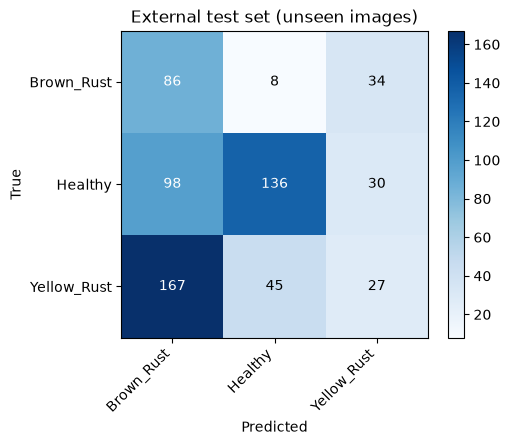

In [4]:
correct = sum(p == t for p, t in zip(predictions, unseen_labels))
accuracy = correct / len(unseen_labels)

print(f'Unseen images     : {len(unseen_labels)}')
print(f'Correct           : {correct}')
print(f'External accuracy : {accuracy:.4f}   ({accuracy:.1%})')
print(f'Mean confidence   : {np.mean(confidences):.1%}')
print()
print(classification_report(unseen_labels, predictions,
                            labels=CLASS_NAMES, digits=3, zero_division=0))

cm = confusion_matrix(unseen_labels, predictions, labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('External test set (unseen images)')
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## Step 4 - compare with the reported accuracy

In [5]:
PAPER_VAL_ACCURACY = 0.9900  

print(f'On the dataset (validation split): {PAPER_VAL_ACCURACY:.1%}')
print(f'On {len(unseen_labels)} unseen images from another source: {accuracy:.1%}')
print(f'Difference: {(accuracy - PAPER_VAL_ACCURACY) * 100:+.1f} percentage points\n')

drop = PAPER_VAL_ACCURACY - accuracy
if drop < 0.02:
    print('The accuracy holds up on images from a different source.')
    print('That is a stronger claim than the paper makes, and worth stating.')
elif drop < 0.15:
    print('A moderate drop. The model generalises, but not as well as the headline')
    print('number suggests. Report both numbers, not just the higher one.')
else:
    print('A large drop. The reported accuracy is specific to this dataset and does')
    print('not transfer to photos collected elsewhere - the main finding of this test.')

On the dataset (validation split): 99.0%
On 631 unseen images from another source: 39.5%
Difference: -59.5 percentage points

A large drop. The reported accuracy is specific to this dataset and does
not transfer to photos collected elsewhere - the main finding of this test.


In [6]:
def centre_crop(image, fraction=0.5):
    """Keep the middle square of the picture - closer to a single-leaf close-up."""
    width, height = image.size
    side = int(min(width, height) * fraction)
    left, top = (width - side) // 2, (height - side) // 2
    return image.crop((left, top, left + side, top + side))


def classify(paths, crop=False):
    """Predict every image, optionally centre-cropping it first."""
    predicted = []
    for start in range(0, len(paths), BATCH_SIZE):
        images = []
        for path in paths[start:start + BATCH_SIZE]:
            picture = Image.open(path).convert('RGB')
            if crop:
                picture = centre_crop(picture)
            images.append(np.asarray(picture.resize(IMG_SIZE), dtype='float32') / 255.0)
        probs = model.predict(np.stack(images), verbose=0)
        predicted.extend(CLASS_NAMES[i] for i in probs.argmax(axis=1))
    return predicted


cropped_predictions = classify(unseen_paths, crop=True)
cropped_accuracy = sum(p == t for p, t in zip(cropped_predictions, unseen_labels)) / len(unseen_labels)

print(f'Whole photo, resized to 256x256 : {accuracy:.1%}')
print(f'Central half, resized to 256x256: {cropped_accuracy:.1%}')
print(f'Change: {(cropped_accuracy - accuracy) * 100:+.1f} percentage points\n')

print(classification_report(unseen_labels, cropped_predictions,
                            labels=CLASS_NAMES, digits=3, zero_division=0))

if cropped_accuracy - accuracy > 0.05:
    print('Cropping recovers accuracy, so the failure is largely about framing:')
    print('the model needs a close-up of one leaf, not a photograph of a field.')
else:
    print('Cropping does not help, so the gap is not only about framing.')

Whole photo, resized to 256x256 : 39.5%
Central half, resized to 256x256: 35.5%
Change: -4.0 percentage points

              precision    recall  f1-score   support

  Brown_Rust      0.248     0.805     0.379       128
     Healthy      0.832     0.337     0.480       264
 Yellow_Rust      0.296     0.134     0.184       239

    accuracy                          0.355       631
   macro avg      0.459     0.425     0.348       631
weighted avg      0.510     0.355     0.347       631

Cropping does not help, so the gap is not only about framing.
